# MongoDB notebook
In this notebook we will look at some plot that represent the housing market in California, and derive some correlations at the end.


## Importing libraries
First of all we need to import the various libraries we are going to use in this notebook:
- ***os***: it helps to install the needed libraries if absent
- ***pymongo***: allows to connect to a mongoDB server and to perform queries
- ***seaborn***: it is useful for statistical data visualization
- ***pandas***: it is used to build DataFrames to be able to work with seaborn

In [2]:
import os
import pandas as pd

try:
    import pymongo
except:
    os.system("pip install pymongo")
    
try:
    import seaborn as sns
except:
    os.system("pip install seaborn")

We can now connect to the DataBase and go into our collection.

In [3]:
#connecting to the DB, insert the url of the DB you want to connect to
myclient = pymongo.MongoClient("mongodb://localhost:27017/")
mydb = myclient["California_Housing"]
mycol = mydb["Housing"]


Let's check if we connected properly:

In [4]:
print(mycol.count_documents({}))

20433


## Exploring the DataBase
First of all let's use a very simple query to get all the documents in the DB and plot them on a map, in order to see where houses have the most value.

<Axes: xlabel='longitude', ylabel='latitude'>

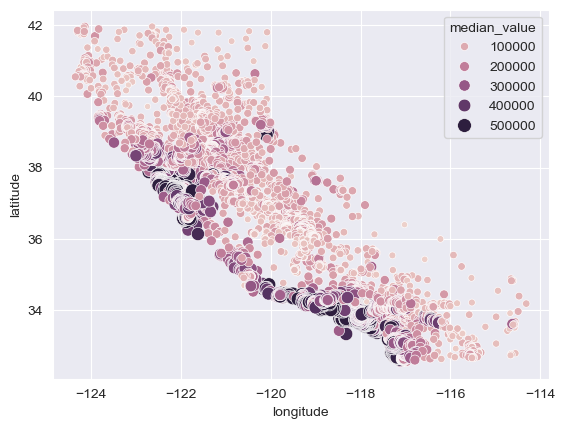

In [5]:
#extract all documents
data = mycol.find({})

#tranform it to a pandas DataFrame to use it with seaborn
list_data = list(data)
pd_data = pd.DataFrame(list_data)

#extract the housing object and transform it to a pandas DataFrame
list_housing = list(pd_data["housing"])
pd_data_housing = pd.DataFrame(list_housing)

#draw a scatterplot to show the median_value respective to the block position
sns.scatterplot(x='longitude',y='latitude', hue=pd_data_housing["median_value"], data=pd_data, size=pd_data_housing["median_value"], sizes=(20, 100))

Now let's have a look the population distribution in California.

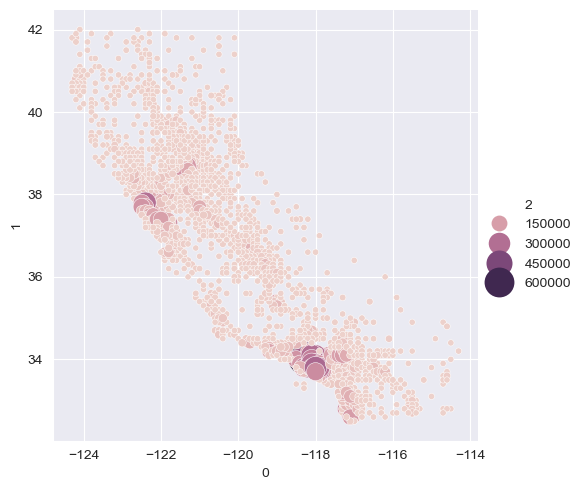

In [6]:
#query the data
pop_data = mycol.find({},{'longitude':1,'latitude':1,'population_and_income':1})

#create a dictionary in which the keys are the coordinates (round up to the first decimal) and the values are the sum of the population in that coordinate
pop_data = list(pop_data)
pop_dict = {}
for i in pop_data:
    i['longitude'] = round(i['longitude'], 1)
    i['latitude'] = round(i['latitude'], 1)
    if (i['longitude'], i['latitude']) not in pop_dict:
        pop_dict[i['longitude'], i['latitude']] = i['population_and_income']['population']       
    else:
        pop_dict[i['longitude'], i['latitude']] += i['population_and_income']['population']
        
#repopulate the list
pop_data = []
for elem in pop_dict.keys():
    elem_list = [elem[0], elem[1], pop_dict.get(elem)]
    pop_data.append(elem_list)
    
#create the dataframe
pop_data = pd.DataFrame(pop_data)
#draw the plot
sns.relplot(x=0, y=1, hue=2, data=pop_data, size=2, sizes=(20,500))

The 4 highlighted points are (from North to South): San Francisco, San Josè, Los Angeles and San Diego, the 4 most crowded cities in California.

Looking at the two plots, we can see that population seems not to be strongly related to the houses' value, but we will have a look on it in depth later.

## The most crowded cities in California
Let's now take a look at the pricing of houses and at the median_income in the most crowded cities in California, which are Los Angeles, San Francisco, San Diego and San Jose.

### Los Angeles

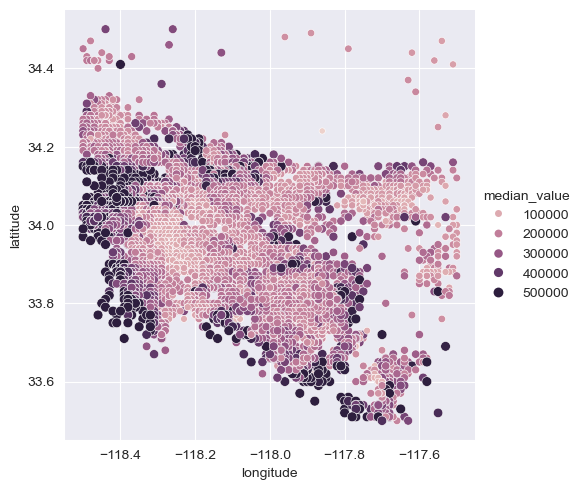

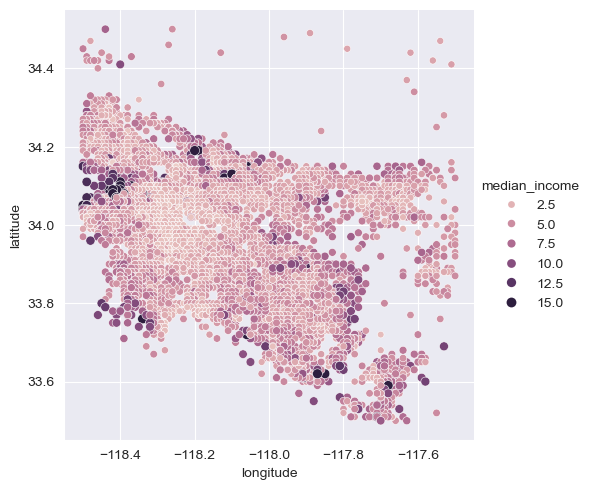

In [7]:
#Los Angeles
los_angeles_data = mycol.aggregate([
    {
        "$match": {
            "longitude": {"$gte": -118.5, "$lte": -117.5},
            "latitude": {"$gte": 33.5, "$lte": 34.5},
        }
    }
])

#extract the DataFrame
los_angeles_data = list(los_angeles_data)
los_angeles_data = pd.DataFrame(los_angeles_data)

#extract the housing subdocument
data_housing_la = list(los_angeles_data["housing"])
data_housing_la = pd.DataFrame(data_housing_la)

#draw the graph
sns.relplot(x="longitude", y="latitude", hue=data_housing_la["median_value"], data=los_angeles_data, size=data_housing_la["median_value"], sizes=(20, 50))

#extracting the population subdocument
data_pop_la = list(los_angeles_data["population_and_income"])
data_pop_la = pd.DataFrame(data_pop_la)

#draw the graph
sns.relplot(x="longitude", y="latitude", hue=data_pop_la["median_income"], data=los_angeles_data, size=data_pop_la["median_income"], sizes=(20, 50))

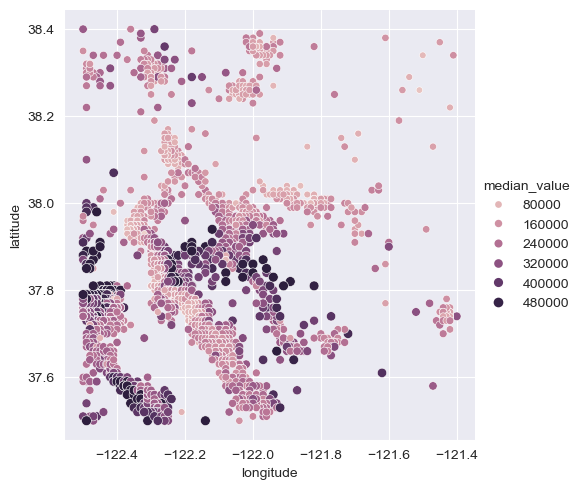

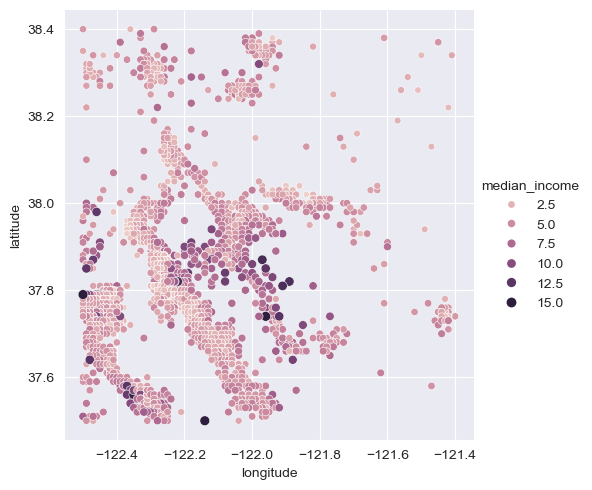

In [8]:
#San Francisco
san_francisco_data = mycol.aggregate([
    {
        "$match": {
            "longitude": {"$gte": -122.5, "$lte": -121.4},
            "latitude": {"$gte": 37.5, "$lte": 38.4},
        }
    }
])

#extrct the DataFrame
san_francisco_data = list(san_francisco_data)
san_francisco_data = pd.DataFrame(san_francisco_data)

#extract the housing subdocument
data_housing_sf = list(san_francisco_data["housing"])
data_housing_sf = pd.DataFrame(data_housing_sf)

#draw the graph
sns.relplot(x="longitude", y="latitude", hue=data_housing_sf["median_value"], data=san_francisco_data, size=data_housing_sf["median_value"], sizes=(20, 50))

#extract the population subdocument
data_pop_sf = list(san_francisco_data["population_and_income"])
data_pop_sf = pd.DataFrame(data_pop_sf)

#draw the graph
sns.relplot(x="longitude", y="latitude", hue=data_pop_sf["median_income"], data=san_francisco_data, size=data_pop_sf["median_income"], sizes=(20, 50))

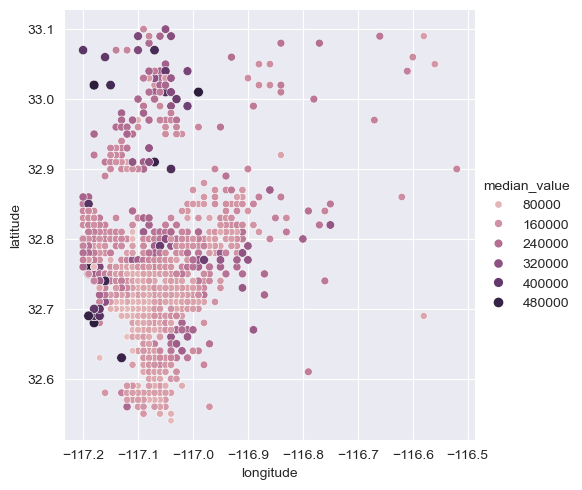

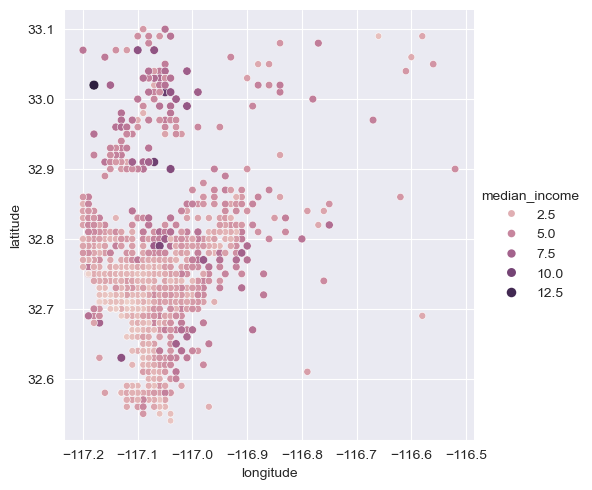

In [9]:
#San Diego
san_diego_data = mycol.aggregate([
    {
        "$match": {
            "longitude": {"$gte": -117.2, "$lte": -116.5},
            "latitude": {"$gte": 32.5, "$lte": 33.1},
        }
    }
])

#extrat the DataFrame
san_diego_data = list(san_diego_data)
san_diego_data = pd.DataFrame(san_diego_data)

#extract the housing subdocument
data_housing_sd = list(san_diego_data["housing"])
data_housing_sd = pd.DataFrame(data_housing_sd)

#draw the graph
sns.relplot(x="longitude", y="latitude", hue=data_housing_sd["median_value"], data=san_diego_data, size=data_housing_sd["median_value"], sizes=(20, 50))

#extract the population subdocument
data_pop_sd = list(san_diego_data["population_and_income"])
data_pop_sd = pd.DataFrame(data_pop_sd)

#draw the graph
sns.relplot(x="longitude", y="latitude", hue=data_pop_sd["median_income"], data=san_diego_data, size=data_pop_sd["median_income"], sizes=(20, 50))

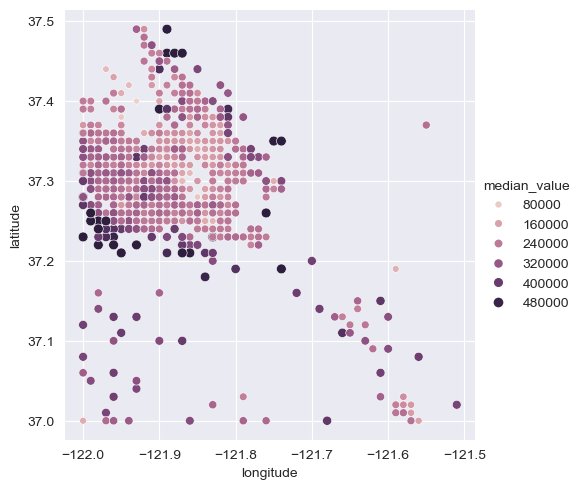

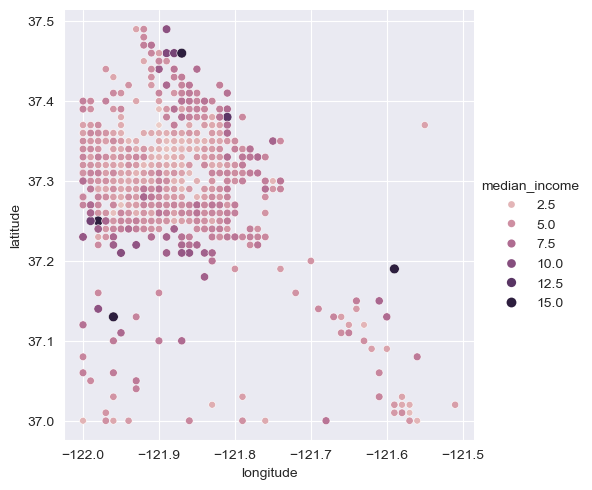

In [10]:
#San Josè
san_jose_data = mycol.aggregate([
    {
        "$match": {
            "longitude": {"$gte": -122.0, "$lte": -121.5},
            "latitude": {"$gte": 37.0, "$lte": 37.5},
        }
    }
])

#extract the DataFrame
san_jose_data = list(san_jose_data)
san_jose_data = pd.DataFrame(san_jose_data)

#extract the housing subdocument
data_housing_sj = list(san_jose_data["housing"])
data_housing_sj = pd.DataFrame(data_housing_sj)

#draw the graph
sns.relplot(x="longitude", y="latitude", hue=data_housing_sj["median_value"], data=san_jose_data, size=data_housing_sj["median_value"], sizes=(20, 50))

#extract the population subdocument
data_pop_sj = list(san_jose_data["population_and_income"])
data_pop_sj = pd.DataFrame(data_pop_sj)

#draw the graph
sns.relplot(x="longitude", y="latitude", hue=data_pop_sj["median_income"], data=san_jose_data, size=data_pop_sj["median_income"], sizes=(20, 50))

Looking at these graphs we can state almost for sure that median income has a good correlation with the houses' median value, at least for houses that have a really high value.

## Data correlation
Thanks to seaborn we can also look for data correlation in our DataBase:

<Axes: >

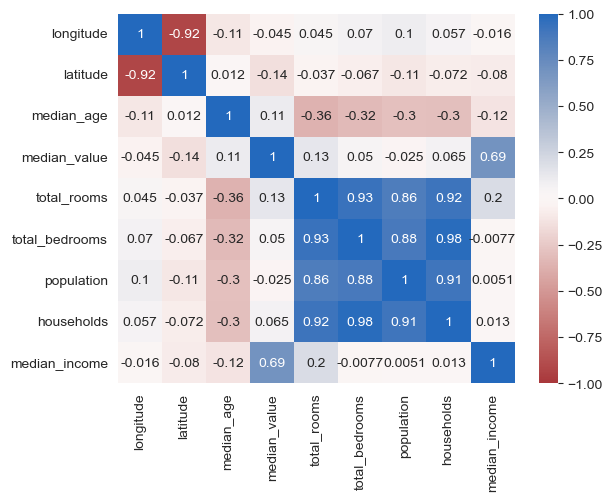

In [11]:
#query all the documents and leave out not correlating data
data_two = mycol.find({},{"_id":0, "ocean_proximity":0})
data_two = list(data_two)

#create new columns in the list and delete the ones relating to subdocuments
#this way every element in the list does not consist of any Object type
for elem in data_two:
    
    elem['median_age'] = elem['housing']['median_age']
    elem['median_value'] = elem['housing']['median_value']
    elem['total_rooms'] = elem['housing']['rooms']['total']
    elem['total_bedrooms'] = elem['housing']['rooms']['bedrooms']
    
    del elem['housing']
    
    elem['population'] = elem['population_and_income']['population']
    elem['households'] = elem['population_and_income']['households']
    elem['median_income'] = elem['population_and_income']['median_income']
    
    del elem['population_and_income']

data_two = pd.DataFrame(data_two)

#compute correlations between -1 and 1
sns.heatmap(data_two.corr(), annot=True, cmap="vlag_r", vmin=-1, vmax=1)

We can derive some correlation from this graph:
- data regarding total_rooms, total_bedrooms, population and households are strongly related. It was expected as a higher number of rooms usually corresponds to more people living and working in that house
- median_income and median_value are somewhat related, but not as strongly as someone might expect
- median_value is not strongly correlated to the total_rooms
- latitude and longitude are not correlated to the median value. This can be expected because since the California coastline is not parallel to meridians and parallels, there can not be found any strong correlation
- median_age is not related to median_value. This can be explained because old houses can be both very luxurious or not be. On the other hand, new houses can be built for very wealthy people or can be new condominiums in which an apartment does not cost that much.